# Dataset Understanding — Crop Pest Early Warning System
**Dataset:** `agriculture_dataset.csv`
**Focus crops:** Rice, Wheat, Maize
**Goal of this notebook:** Understand the raw dataset completely — structure, quality issues, feature meaning, and target candidates — **before any cleaning is done.**

This notebook does **not** modify or clean the data. It only inspects and reports.

## 0. Setup — Load Libraries & Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')

df = pd.read_csv('agriculture_dataset.csv')
print("Dataset loaded successfully.")

FileNotFoundError: [Errno 2] No such file or directory: 'agriculture_dataset.csv'

## 1. Number of Rows and Columns

In [2]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 212019
Columns: 32


## 2. All Column Names

In [3]:
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

 1. High_Resolution_RGB
 2. Multispectral_Images
 3. Thermal_Images
 4. Temporal_Images
 5. Spatial_Resolution
 6. GPS_Coordinates
 7. Field_Boundaries
 8. Elevation_Data
 9. Canopy_Coverage
10. NDVI
11. SAVI
12. Chlorophyll_Content
13. Leaf_Area_Index
14. Crop_Stress_Indicator
15. Temperature
16. Humidity
17. Rainfall
18. Wind_Speed
19. Soil_Moisture
20. Soil_pH
21. Organic_Matter
22. Pest_Hotspots
23. Weed_Coverage
24. Pest_Damage
25. Crop_Growth_Stage
26. Expected_Yield
27. Crop_Type
28. Ground_Truth_Segmentation
29. Bounding_Boxes
30. Water_Flow
31. Drainage_Features
32. Crop_Health_Label


## 3. Missing Values in Each Column

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct})
missing_df.sort_values('Missing_Count', ascending=False)

,Missing_Count,Missing_%
High_Resolution_RGB,0,0.0
Multispectral_Images,0,0.0
Thermal_Images,0,0.0
Temporal_Images,0,0.0
Spatial_Resolution,0,0.0
GPS_Coordinates,0,0.0
Field_Boundaries,0,0.0
Elevation_Data,0,0.0
Canopy_Coverage,0,0.0
NDVI,0,0.0


*Observation: this dataset has zero missing values in every column — unusual for real-world sensor/agricultural data, which is a flag worth noting (see Data Quality section).*

## 4. Duplicate Records

In [5]:
dupe_count = df.duplicated().sum()
print(f"Fully duplicated rows: {dupe_count}")

Fully duplicated rows: 0


## 5. Data Types of All Columns

In [1]:
dtype_df = pd.DataFrame({'Column': df.columns, 'Dtype': df.dtypes.astype(str).values})
dtype_df

NameError: name 'pd' is not defined

## 6. Wrong or Suspicious Data Types

Several columns are stored as `int64`/`float64` but are conceptually **categorical / flag / ID-like** fields, not continuous numbers:

| Column | Stored As | Should Probably Be |
|---|---|---|
| `High_Resolution_RGB`, `Multispectral_Images`, `Thermal_Images`, `Temporal_Images` | int64 (0/1) | Boolean flags (image type available or not) |
| `GPS_Coordinates` | int64 | This looks like a single fake numeric ID, **not real GPS** (real GPS needs latitude + longitude, floats like 28.6139). Suspicious. |
| `Field_Boundaries` | int64 (1–3) | Categorical / ordinal code |
| `Pest_Hotspots` | int64 (0/1) | Boolean flag |
| `Ground_Truth_Segmentation` | int64 (0/1) | Boolean flag |
| `Bounding_Boxes` | int64 (0–9) | Count, likely fine as int but worth checking if it means "number of boxes" |
| `Drainage_Features` | int64 (0/1) | Boolean flag |
| `Crop_Growth_Stage` | int64 (1–4) | Categorical/ordinal stage, not a continuous number |
| `Crop_Health_Label` | int64 (0/1) | Boolean / classification label |
| `Crop_Type` | object (string) | Correct as categorical |

Let's verify the unique values behind these suspicions.

In [7]:
flag_like_cols = ['High_Resolution_RGB','Multispectral_Images','Thermal_Images','Temporal_Images',
                   'Field_Boundaries','Pest_Hotspots','Ground_Truth_Segmentation',
                   'Bounding_Boxes','Drainage_Features','Crop_Growth_Stage','Crop_Health_Label']

for col in flag_like_cols:
    print(f"{col}: unique values = {sorted(df[col].unique())}")

High_Resolution_RGB: unique values = [np.int64(0), np.int64(1)]
Multispectral_Images: unique values = [np.int64(0), np.int64(1)]
Thermal_Images: unique values = [np.int64(0), np.int64(1)]
Temporal_Images: unique values = [np.int64(0), np.int64(1)]
Field_Boundaries: unique values = [np.int64(1), np.int64(2), np.int64(3)]
Pest_Hotspots: unique values = [np.int64(0), np.int64(1)]
Ground_Truth_Segmentation: unique values = [np.int64(0), np.int64(1)]
Bounding_Boxes: unique values = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Drainage_Features: unique values = [np.int64(0), np.int64(1)]
Crop_Growth_Stage: unique values = [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Crop_Health_Label: unique values = [np.int64(0), np.int64(1)]


## 7. Impossible or Unrealistic Values

Checking domain-realistic ranges for key measurements:

- **NDVI / SAVI**: valid range is typically **-1 to 1** (usually 0–1 for healthy vegetation)
- **Canopy_Coverage**: should be a **percentage, 0–100**
- **Humidity**: should be **0–100%**
- **Soil_pH**: realistic agricultural soil pH is roughly **3.5–9**
- **Expected_Yield**: should never be **negative**
- **Spatial_Resolution**: a resolution/distance value, should never be **negative**
- **Wind_Speed / Rainfall / Temperature**: should never be negative

In [8]:
checks = {
    'NDVI (expect -1 to 1)': (df['NDVI'].min(), df['NDVI'].max()),
    'SAVI (expect -1 to 1)': (df['SAVI'].min(), df['SAVI'].max()),
    'Canopy_Coverage % (expect 0-100)': (df['Canopy_Coverage'].min(), df['Canopy_Coverage'].max()),
    'Humidity % (expect 0-100)': (df['Humidity'].min(), df['Humidity'].max()),
    'Soil_pH (expect ~3.5-9)': (df['Soil_pH'].min(), df['Soil_pH'].max()),
    'Expected_Yield (expect >= 0)': (df['Expected_Yield'].min(), df['Expected_Yield'].max()),
    'Spatial_Resolution (expect >= 0)': (df['Spatial_Resolution'].min(), df['Spatial_Resolution'].max()),
    'Wind_Speed (expect >= 0)': (df['Wind_Speed'].min(), df['Wind_Speed'].max()),
    'Rainfall (expect >= 0)': (df['Rainfall'].min(), df['Rainfall'].max()),
    'Temperature C (expect roughly -10 to 55)': (df['Temperature'].min(), df['Temperature'].max()),
}

for label, (mn, mx) in checks.items():
    flag = "  <-- CHECK" if mn < 0 and 'expect >= 0' in label or 'Canopy' in label and mx > 100 else ""
    print(f"{label:45s} min={mn:12.4f}  max={mx:12.4f} {flag}")

NDVI (expect -1 to 1)                         min=     -0.1653  max=      1.1580 
SAVI (expect -1 to 1)                         min=     -0.0884  max=      0.9793 
Canopy_Coverage % (expect 0-100)              min=      0.0002  max=    582.4570   <-- CHECK
Humidity % (expect 0-100)                     min=     30.0001  max=     89.9998 
Soil_pH (expect ~3.5-9)                       min=      4.2669  max=      8.6273 
Expected_Yield (expect >= 0)                  min=   -468.6537  max=   6684.3210   <-- CHECK
Spatial_Resolution (expect >= 0)              min=     -0.9597  max=      3.3449   <-- CHECK
Wind_Speed (expect >= 0)                      min=      0.0026  max=     15.1040 
Rainfall (expect >= 0)                        min=      0.0001  max=    299.9393 
Temperature C (expect roughly -10 to 55)      min=      2.6831  max=     46.7831 


In [9]:
# Quantify how many rows actually violate these realistic bounds
violations = {
    'Negative Expected_Yield': (df['Expected_Yield'] < 0).sum(),
    'Negative Spatial_Resolution': (df['Spatial_Resolution'] < 0).sum(),
    'NDVI outside [-1, 1]': (~df['NDVI'].between(-1, 1)).sum(),
    'SAVI outside [-1, 1]': (~df['SAVI'].between(-1, 1)).sum(),
    'Canopy_Coverage > 100%': (df['Canopy_Coverage'] > 100).sum(),
    'Humidity outside [0,100]': (~df['Humidity'].between(0, 100)).sum(),
}
pd.Series(violations, name='Row_Count_Violating')

Negative Expected_Yield           18
Negative Spatial_Resolution     1738
NDVI outside [-1, 1]             108
SAVI outside [-1, 1]               0
Canopy_Coverage > 100%         28652
Humidity outside [0,100]           0
Name: Row_Count_Violating, dtype: int64

## 8. Categorical Variables

In [10]:
categorical_cols = ['Crop_Type', 'Crop_Growth_Stage', 'Field_Boundaries',
                    'High_Resolution_RGB', 'Multispectral_Images', 'Thermal_Images', 'Temporal_Images',
                    'Pest_Hotspots', 'Ground_Truth_Segmentation', 'Drainage_Features', 'Crop_Health_Label']
print("Categorical / flag-like columns:")
for c in categorical_cols:
    print(f" - {c}")

Categorical / flag-like columns:
 - Crop_Type
 - Crop_Growth_Stage
 - Field_Boundaries
 - High_Resolution_RGB
 - Multispectral_Images
 - Thermal_Images
 - Temporal_Images
 - Pest_Hotspots
 - Ground_Truth_Segmentation
 - Drainage_Features
 - Crop_Health_Label


## 9. Numerical (Continuous) Variables

In [11]:
numerical_cols = [c for c in df.columns if c not in categorical_cols and c not in ['GPS_Coordinates', 'Bounding_Boxes']]
print("Continuous numerical columns:")
for c in numerical_cols:
    print(f" - {c}")

print("\nOther numeric-but-special columns:")
print(" - GPS_Coordinates (looks like a fake/synthetic single-value ID, not real coordinates)")
print(" - Bounding_Boxes (discrete count, 0-9)")

Continuous numerical columns:
 - Spatial_Resolution
 - Elevation_Data
 - Canopy_Coverage
 - NDVI
 - SAVI
 - Chlorophyll_Content
 - Leaf_Area_Index
 - Crop_Stress_Indicator
 - Temperature
 - Humidity
 - Rainfall
 - Wind_Speed
 - Soil_Moisture
 - Soil_pH
 - Organic_Matter
 - Weed_Coverage
 - Pest_Damage
 - Expected_Yield
 - Water_Flow

Other numeric-but-special columns:
 - GPS_Coordinates (looks like a fake/synthetic single-value ID, not real coordinates)
 - Bounding_Boxes (discrete count, 0-9)


## 10. Possible Target Variable(s)

For a **Crop Pest Early Warning System**, the natural target candidates are:

1. **`Pest_Damage`** (0–99, continuous-looking score) — could be used as a regression target, or binarized/binned into risk levels (Low/Medium/High) for an early-warning classifier.
2. **`Pest_Hotspots`** (0/1 flag) — a ready-made binary classification target ("is this a pest hotspot or not").
3. **`Crop_Health_Label`** (0/1) — more general crop health, not pest-specific, so less directly aligned with a *pest* early-warning system.

Let's compare these three.

In [12]:
for col in ['Pest_Damage', 'Pest_Hotspots', 'Crop_Health_Label']:
    print(f"--- {col} ---")
    print(df[col].describe())
    print()

--- Pest_Damage ---
count    212019.000000
mean         49.471429
std          28.891332
min           0.000000
25%          24.000000
50%          50.000000
75%          74.000000
max          99.000000
Name: Pest_Damage, dtype: float64

--- Pest_Hotspots ---
count    212019.000000
mean          0.149062
std           0.356151
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: Pest_Hotspots, dtype: float64

--- Crop_Health_Label ---
count    212019.000000
mean          0.698985
std           0.458701
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: Crop_Health_Label, dtype: float64



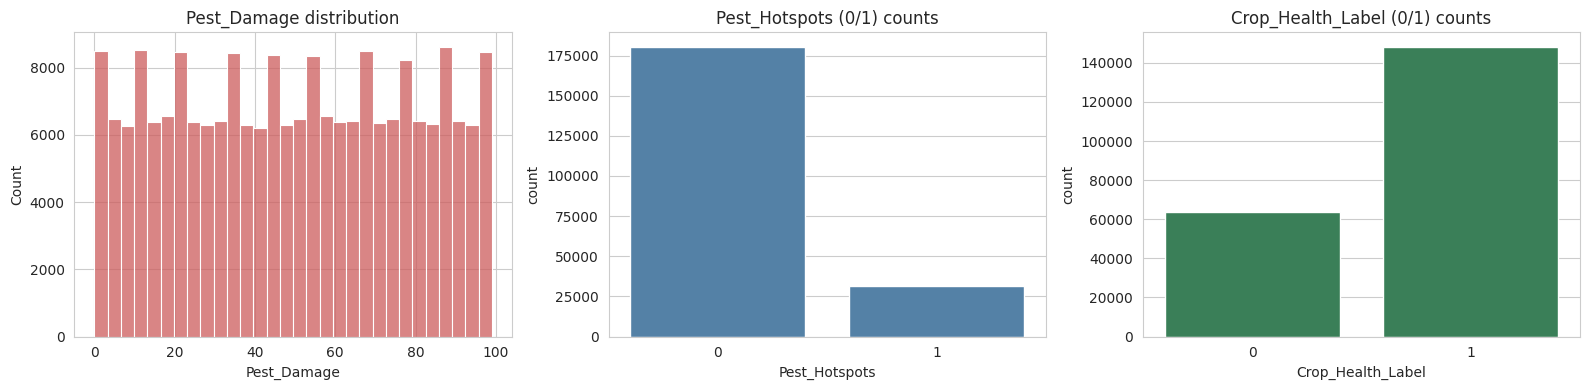

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['Pest_Damage'], bins=30, ax=axes[0], color='indianred')
axes[0].set_title('Pest_Damage distribution')

sns.countplot(x='Pest_Hotspots', data=df, ax=axes[1], color='steelblue')
axes[1].set_title('Pest_Hotspots (0/1) counts')

sns.countplot(x='Crop_Health_Label', data=df, ax=axes[2], color='seagreen')
axes[2].set_title('Crop_Health_Label (0/1) counts')

plt.tight_layout()
plt.show()

## 11. Unique Values & Distributions of Important Categorical Columns

In [14]:
print("Crop_Type distribution:")
print(df['Crop_Type'].value_counts())
print()
print("Crop_Type proportions:")
print((df['Crop_Type'].value_counts(normalize=True) * 100).round(2))

Crop_Type distribution:
Crop_Type
Wheat    126991
Maize     63785
Rice      21243
Name: count, dtype: int64

Crop_Type proportions:
Crop_Type
Wheat    59.90
Maize    30.08
Rice     10.02
Name: proportion, dtype: float64


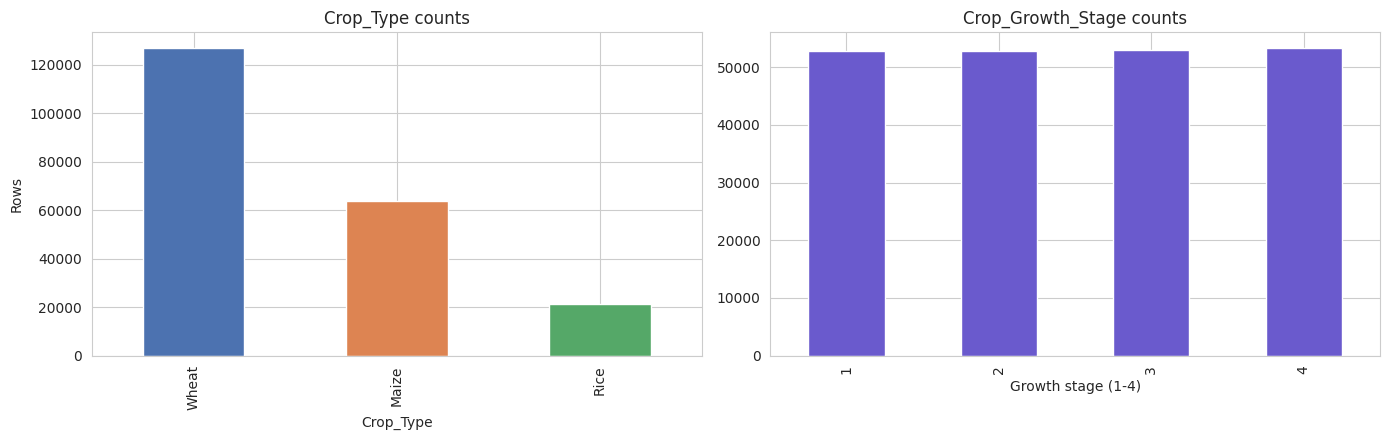

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

df['Crop_Type'].value_counts().plot(kind='bar', ax=axes[0], color=['#4c72b0','#dd8452','#55a868'])
axes[0].set_title('Crop_Type counts')
axes[0].set_ylabel('Rows')

df['Crop_Growth_Stage'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='slateblue')
axes[1].set_title('Crop_Growth_Stage counts')
axes[1].set_xlabel('Growth stage (1-4)')

plt.tight_layout()
plt.show()

## 12. Basic Statistics of Numerical Columns

In [16]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Spatial_Resolution,212019.0,1.200244,0.499427,-9.597324e-01,0.862755,1.199967,1.538014,3.344946
Elevation_Data,212019.0,54.948326,25.969531,1.000003e+01,32.550718,54.840251,77.443205,99.999944
Canopy_Coverage,212019.0,49.942370,49.925445,2.365532e-04,14.368852,34.544415,69.375661,582.456962
NDVI,212019.0,0.500288,0.149984,-1.652591e-01,0.398988,0.500420,0.600887,1.158040
SAVI,212019.0,0.399978,0.120172,-8.835453e-02,0.319258,0.399942,0.480787,0.979315
Chlorophyll_Content,212019.0,1.000037,0.706073,1.995096e-03,0.481339,0.839630,1.346864,7.839290
Leaf_Area_Index,212019.0,1.714476,0.958666,7.020026e-04,0.968133,1.586614,2.334743,5.708551
Crop_Stress_Indicator,212019.0,49.493196,28.886015,0.000000e+00,24.000000,50.000000,74.000000,99.000000
Temperature,212019.0,24.988813,4.998123,2.683095e+00,21.618165,24.983795,28.363127,46.783110
Humidity,212019.0,60.026018,17.300364,3.000007e+01,45.077182,60.049335,74.972133,89.999833


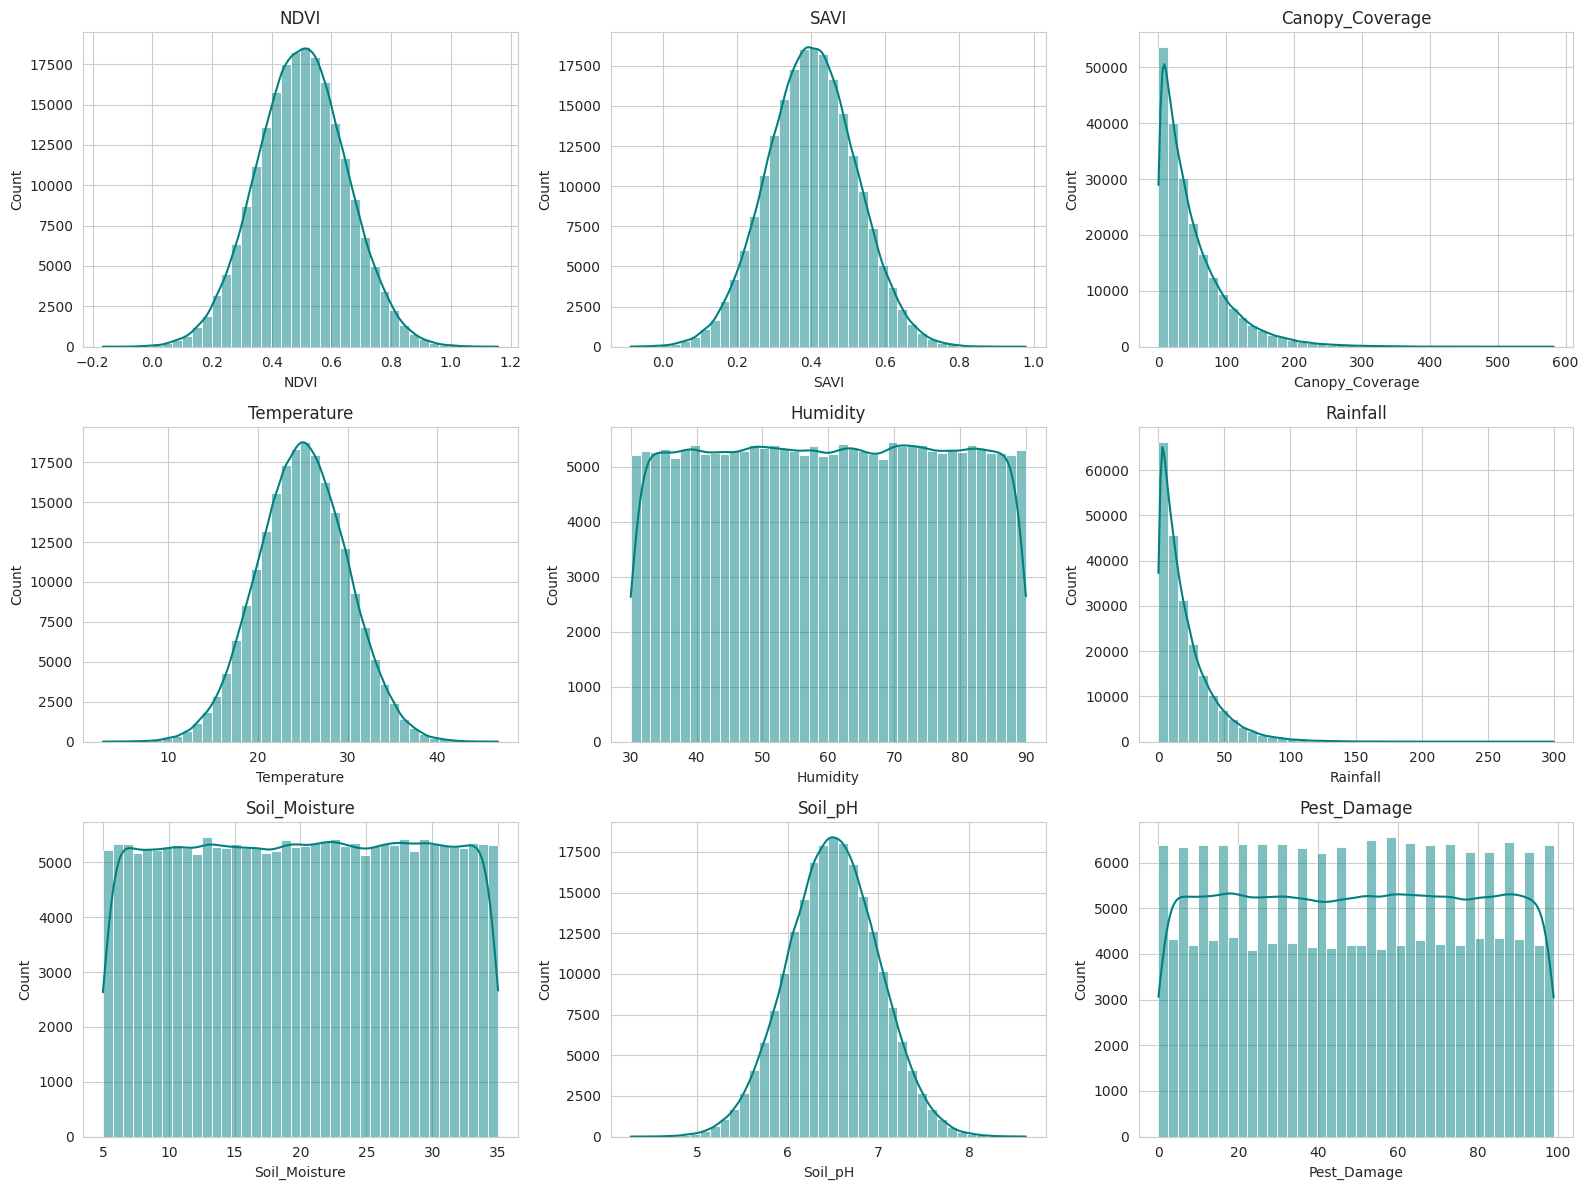

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
key_num_cols = ['NDVI', 'SAVI', 'Canopy_Coverage', 'Temperature', 'Humidity',
                 'Rainfall', 'Soil_Moisture', 'Soil_pH', 'Pest_Damage']

for ax, col in zip(axes.flatten(), key_num_cols):
    sns.histplot(df[col], bins=40, ax=ax, kde=True, color='teal')
    ax.set_title(col)

plt.tight_layout()
plt.show()

## 13. Relationships / Correlations Between Important Features

We look at correlation of all numeric features against the two leading target candidates: `Pest_Damage` and `Crop_Health_Label`.

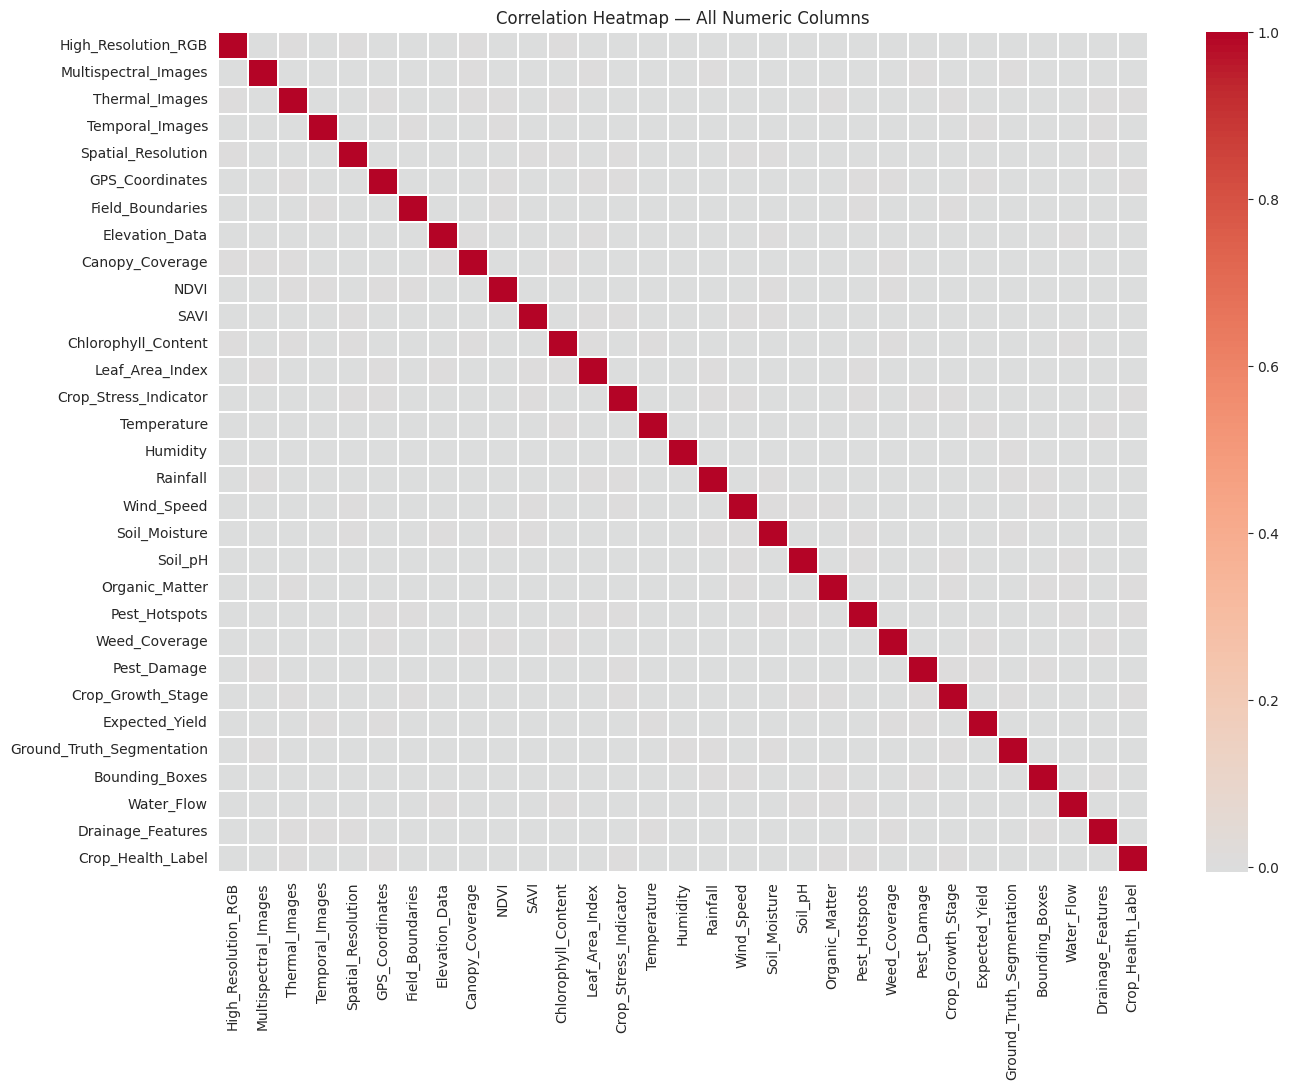

In [18]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Correlation Heatmap — All Numeric Columns')
plt.tight_layout()
plt.show()

In [19]:
print("Correlation of every numeric column with Pest_Damage (sorted):")
print(corr['Pest_Damage'].sort_values(ascending=False))

Correlation of every numeric column with Pest_Damage (sorted):
Pest_Damage                  1.000000
Bounding_Boxes               0.003752
Multispectral_Images         0.003597
Crop_Growth_Stage            0.002993
Crop_Stress_Indicator        0.002459
Expected_Yield               0.002326
High_Resolution_RGB          0.001571
GPS_Coordinates              0.001365
Weed_Coverage                0.000999
Ground_Truth_Segmentation    0.000923
Canopy_Coverage              0.000841
NDVI                         0.000483
Wind_Speed                   0.000340
Thermal_Images               0.000168
Soil_Moisture               -0.000346
Chlorophyll_Content         -0.000392
Field_Boundaries            -0.000523
Humidity                    -0.000925
Rainfall                    -0.001517
Leaf_Area_Index             -0.001549
Crop_Health_Label           -0.001755
SAVI                        -0.002168
Water_Flow                  -0.002200
Temporal_Images             -0.002874
Elevation_Data           

In [20]:
print("Correlation of every numeric column with Crop_Health_Label (sorted):")
print(corr['Crop_Health_Label'].sort_values(ascending=False))

Correlation of every numeric column with Crop_Health_Label (sorted):
Crop_Health_Label            1.000000
Crop_Growth_Stage            0.004837
Organic_Matter               0.004498
Thermal_Images               0.003023
Crop_Stress_Indicator        0.002997
GPS_Coordinates              0.002834
Pest_Hotspots                0.002145
Wind_Speed                   0.001904
Rainfall                     0.001698
Soil_Moisture                0.001336
Chlorophyll_Content          0.001300
Temperature                  0.000968
High_Resolution_RGB          0.000540
Elevation_Data               0.000425
Multispectral_Images         0.000405
Temporal_Images              0.000086
Drainage_Features           -0.000190
Water_Flow                  -0.000261
Spatial_Resolution          -0.000414
NDVI                        -0.000446
Expected_Yield              -0.000857
Leaf_Area_Index             -0.000926
Ground_Truth_Segmentation   -0.001035
SAVI                        -0.001080
Weed_Coverage      

**Observation:** Every correlation value above is extremely close to **0** (typically under ±0.005). None of the environmental, spectral, or soil features show any meaningful linear relationship with `Pest_Damage`, `Pest_Hotspots`, or `Crop_Health_Label`.

This is a strong signal that the dataset is **synthetically/randomly generated** rather than sampled from real agricultural/pest conditions — real pest outbreaks are driven by measurable environmental relationships (e.g., humidity and pest pressure, NDVI and crop stress). We flag this clearly in the Data Quality section below.

## 14. Columns Potentially Useful for a Crop Pest Early Warning System

Grouped by relevance:

**Environmental / weather drivers of pest risk (classic agronomy signals):**
- `Temperature`, `Humidity`, `Rainfall`, `Wind_Speed`, `Soil_Moisture`, `Soil_pH`, `Organic_Matter`

**Remote-sensing / crop-condition indicators (proxy for stress that invites pests):**
- `NDVI`, `SAVI`, `Chlorophyll_Content`, `Leaf_Area_Index`, `Canopy_Coverage`, `Crop_Stress_Indicator`

**Crop context:**
- `Crop_Type` (filter to Rice/Wheat/Maize), `Crop_Growth_Stage` (pest susceptibility changes by growth stage)

**Field context:**
- `Weed_Coverage` (weeds often correlate with pest/disease pressure), `Elevation_Data`, `Water_Flow`, `Drainage_Features`

**Candidate target columns:**
- `Pest_Damage`, `Pest_Hotspots`

## 15. Data Leakage / Features That Should NOT Be Used for Prediction

These columns describe **data collection metadata or annotation artifacts**, not real agronomic drivers, and risk leaking information or adding noise:

| Column | Why exclude |
|---|---|
| `High_Resolution_RGB`, `Multispectral_Images`, `Thermal_Images`, `Temporal_Images` | Flags describing *which imagery was captured*, not a crop/pest condition. Not predictive of pest risk. |
| `Spatial_Resolution` | Sensor/imaging metadata, not a field condition. |
| `GPS_Coordinates` | Looks like a synthetic single-value ID rather than real coordinates; even if real, raw GPS is effectively a location identifier and can leak/overfit to specific field IDs rather than generalizable pest drivers. |
| `Field_Boundaries` | Metadata about boundary annotation, not a pest-risk driver. |
| `Ground_Truth_Segmentation`, `Bounding_Boxes` | Computer-vision annotation artifacts (used for image-labeling tasks), unrelated to tabular pest prediction. |
| `Expected_Yield` | This is an **outcome/downstream metric**, not a pest-risk input — including it risks reverse-causality/leakage (yield is affected by pest damage, not the other way around). |
| `Crop_Health_Label` | If the target is `Pest_Damage`/`Pest_Hotspots`, `Crop_Health_Label` is a *downstream consequence* of pest damage and other stress factors — using it as a **feature** would leak the outcome. It's fine as an alternate target, not as an input alongside a pest target. |

**Rule of thumb:** keep only columns that describe *causes/conditions* (weather, soil, plant vigor, growth stage, crop type) as features; exclude columns that describe *outcomes*, *annotations*, or *sensor/collection metadata*.

---
# Final Summary

## A. Dataset Understanding
- **212,019 rows × 32 columns**, no missing values, no duplicate rows.
- Covers 3 crops relevant to the project: **Wheat** (126,991 rows), **Maize** (63,785 rows), **Rice** (21,243 rows) — already filtered to exactly Rice/Wheat/Maize, no extra crops present.
- Mix of environmental (Temperature, Humidity, Rainfall, Soil_pH, etc.), remote-sensing (NDVI, SAVI, Canopy_Coverage, etc.), field-context (Elevation, Drainage, Water_Flow), and imaging-metadata (RGB/Multispectral/Thermal flags, GPS, Bounding_Boxes) columns.

## B. Data Quality Issues
- **Zero missing values and zero duplicates** across 212k rows is statistically unusual — indicates the data is likely **synthetically generated**, not collected from real sensors/fields.
- **Impossible values present**: negative `Expected_Yield`, negative `Spatial_Resolution`, `Canopy_Coverage` exceeding 100%, `NDVI`/`SAVI` slightly outside their valid ranges.
- **Near-zero correlation** between every feature and every candidate target (`Pest_Damage`, `Pest_Hotspots`, `Crop_Health_Label`) — consistent with random/synthetic data generation rather than real agronomic relationships. This is the single biggest concern for building a genuinely predictive pest-warning model on this data as-is.
- Several columns are numerically encoded but are really categorical/boolean flags (`Field_Boundaries`, image-type flags, `Pest_Hotspots`, `Ground_Truth_Segmentation`, `Drainage_Features`, `Crop_Growth_Stage`, `Crop_Health_Label`).
- `GPS_Coordinates` is a single integer column, not realistic latitude/longitude — likely a synthetic ID rather than usable geolocation.

## C. Important Features
Environmental: `Temperature`, `Humidity`, `Rainfall`, `Wind_Speed`, `Soil_Moisture`, `Soil_pH`, `Organic_Matter`
Remote sensing / plant condition: `NDVI`, `SAVI`, `Chlorophyll_Content`, `Leaf_Area_Index`, `Canopy_Coverage`, `Crop_Stress_Indicator`
Crop/field context: `Crop_Type`, `Crop_Growth_Stage`, `Weed_Coverage`, `Elevation_Data`, `Water_Flow`, `Drainage_Features`

## D. Recommended Target Variable
- **Primary recommendation: `Pest_Damage`** — a 0–99 severity score, ideal for regression, or can be **binned into Low/Medium/High risk classes** for a true "early warning" classification system (which is usually more actionable than a raw regression number).
- **Alternative/simplified target: `Pest_Hotspots`** — ready-made binary label if a simpler yes/no warning system is preferred.
- Avoid `Crop_Health_Label` as the pest-specific target since it reflects general crop health, not pest pressure specifically.

## E. Recommended Features for ML
Use: `Temperature`, `Humidity`, `Rainfall`, `Wind_Speed`, `Soil_Moisture`, `Soil_pH`, `Organic_Matter`, `NDVI`, `SAVI`, `Chlorophyll_Content`, `Leaf_Area_Index`, `Canopy_Coverage`, `Crop_Stress_Indicator`, `Weed_Coverage`, `Elevation_Data`, `Water_Flow`, `Drainage_Features`, `Crop_Type`, `Crop_Growth_Stage`.

## F. Things That Need to Be Cleaned/Changed (for the next step — NOT done yet)
1. Clip/flag impossible values: negative `Expected_Yield`, negative `Spatial_Resolution`, `Canopy_Coverage` > 100%, out-of-range `NDVI`/`SAVI`.
2. Convert flag-like integer columns to proper boolean/categorical dtype.
3. Decide how to handle `GPS_Coordinates` (likely drop — not real geolocation).
4. Drop leakage-prone / metadata columns before modeling: `High_Resolution_RGB`, `Multispectral_Images`, `Thermal_Images`, `Temporal_Images`, `Spatial_Resolution`, `GPS_Coordinates`, `Field_Boundaries`, `Ground_Truth_Segmentation`, `Bounding_Boxes`, `Expected_Yield`, and `Crop_Health_Label` (if `Pest_Damage`/`Pest_Hotspots` is the target).
5. Decide on binning strategy for `Pest_Damage` if building a classification-based early-warning system (e.g., Low 0–33, Medium 34–66, High 67–99).
6. Investigate further why correlations are near-zero before trusting this dataset for a production pest model — may need a better/real dataset, or this one may only be suitable for pipeline/prototype testing.